In [37]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


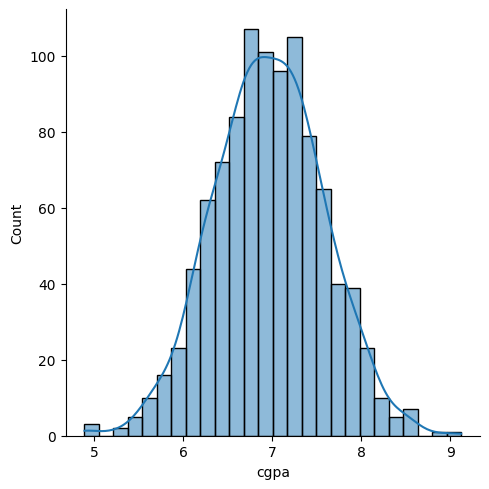

In [39]:
sns.displot(df['cgpa'],kde=True)

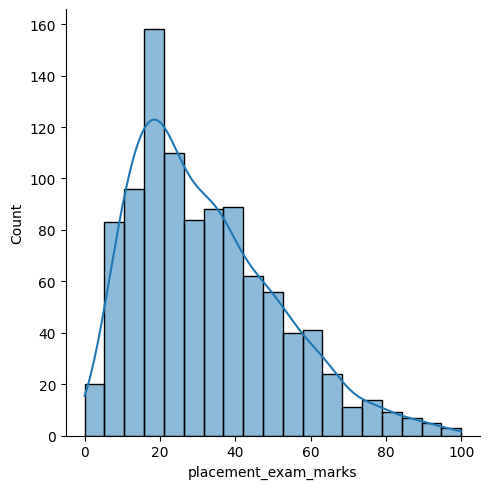

In [40]:
sns.displot(df['placement_exam_marks'],kde=True)

In [41]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [42]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [43]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [44]:
percentile25

np.float64(17.0)

In [45]:
percentile75

np.float64(44.0)

In [46]:
iqr = percentile75 - percentile25

In [47]:
iqr

np.float64(27.0)

<Axes: ylabel='placement_exam_marks'>

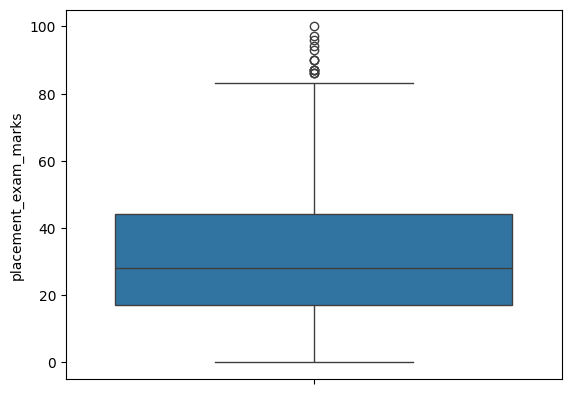

In [48]:
sns.boxplot(df['placement_exam_marks'])

In [49]:
upper_limit = percentile75+1.5 * (iqr)
lower_limit = percentile25-1.5 * (iqr)

In [50]:
upper_limit

np.float64(84.5)

In [51]:
lower_limit

np.float64(-23.5)

In [52]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [53]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


In [54]:
# trimming

new_df = df[df['placement_exam_marks']<upper_limit]

In [55]:
new_df.shape

(985, 3)

<Axes: xlabel='placement_exam_marks'>

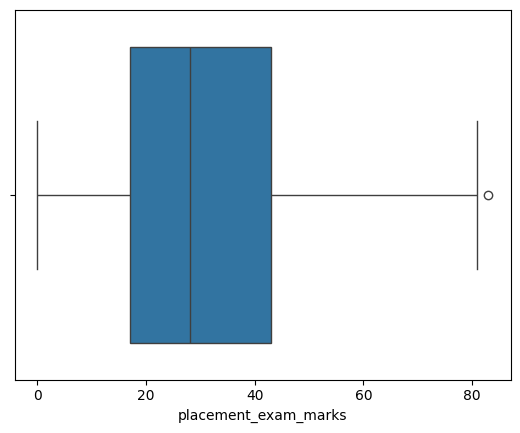

In [56]:
sns.boxplot(x='placement_exam_marks', data=new_df)

In [60]:
# capping

new_df = df.copy()

new_df['placement_exam_marks'] = new_df['placement_exam_marks'].clip(
    upper=upper_limit,
    lower=lower_limit    
)

In [62]:
new_df.shape

(1000, 3)

<Axes: ylabel='placement_exam_marks'>

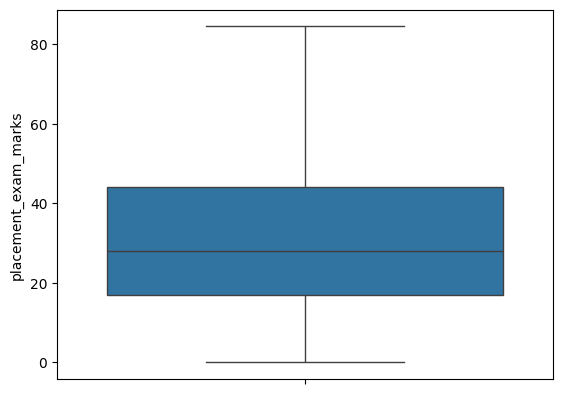

In [65]:
sns.boxplot(new_df['placement_exam_marks'])